# ❤️ Heart Disease Prediction using Machine Learning

## 📌 Project Objective

Heart disease is one of the leading causes of death worldwide. Early prediction can assist healthcare professionals in identifying high-risk patients and taking preventive measures.

In this project, we perform an end-to-end machine learning workflow to predict the presence of heart disease using patient medical attributes.

The notebook includes:

- Data Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Correlation Analysis
- Feature Selection
- Data Preprocessing
- Model Training
- Cross Validation
- Hyperparameter Tuning
- Model Evaluation
- Final Prediction

---

# 📚 Import Libraries


## Libraries Used

- **NumPy** – Numerical computations
- **Pandas** – Data manipulation
- **Matplotlib & Seaborn** – Data visualization
- **Scikit-learn** – Machine Learning algorithms and preprocessing
- **SciPy** – Statistical analysis
- **XGBoost** – Gradient boosting classifier




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 8)
print("Setup Complete: Libraries and visualization styles initialized.")

Setup Complete: Libraries and visualization styles initialized.


In [2]:
# Set visualization style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 8)
print("Setup Complete: Styles and configurations applied.")

Setup Complete: Styles and configurations applied.


# 📂 Load Dataset

In [3]:
df=pd.read_csv("Heart_Disease_Prediction.csv")

In [4]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


# 🔍 Data Understanding



In [5]:
df.shape

(270, 14)

In [6]:
df.describe()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [7]:
df.isna().sum()

Age                        0
Gender                     0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Gender                   270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [9]:
df["Heart Disease"]=df["Heart Disease"].map({"Presence" : 1,"Absence":0})
df=df.astype(int)

# 📊 Exploratory Data Analysis (EDA)


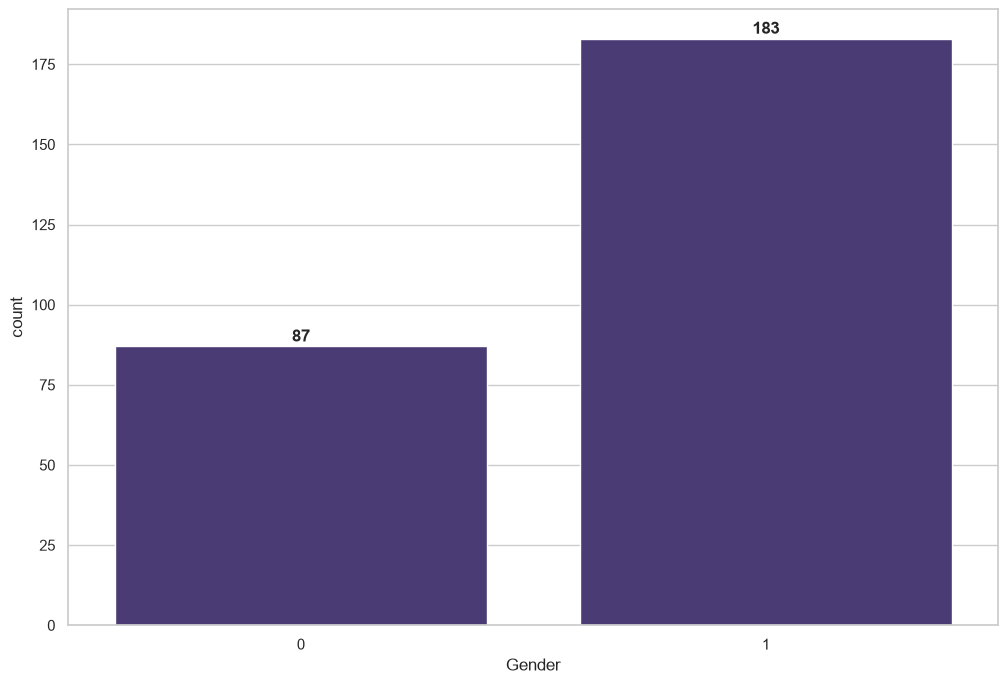

In [10]:
ax=sns.countplot(x="Gender",data=df,)
for container in ax.containers:
    ax.bar_label(container,padding=1,fontweight='bold',label_type='edge')


<Axes: xlabel='Age', ylabel='Count'>

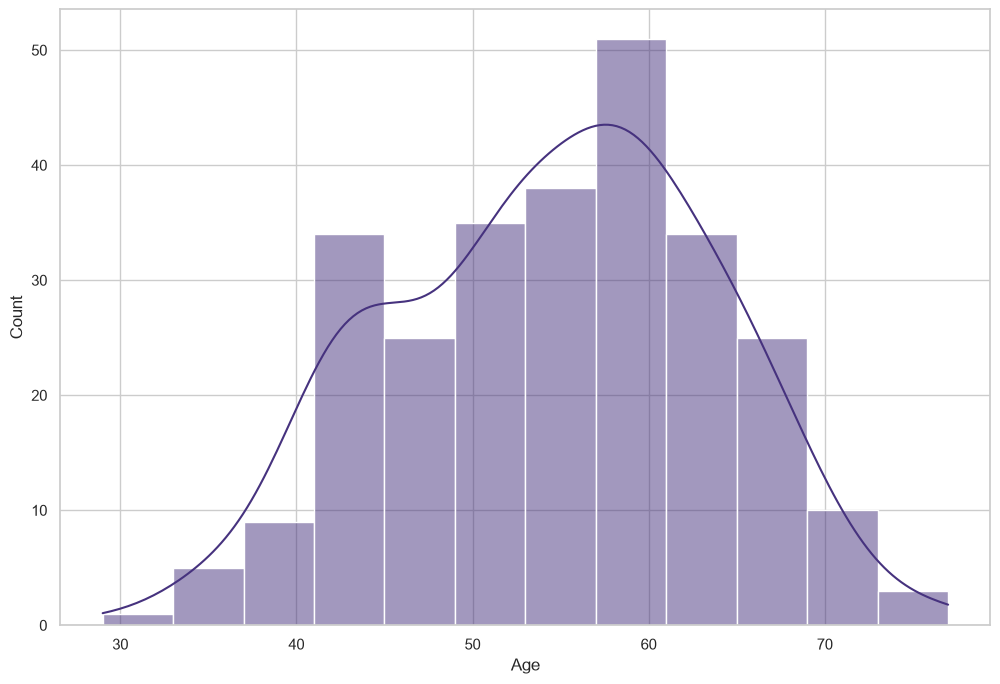

In [11]:
sns.histplot(x="Age",data=df,kde=True)

<Axes: xlabel='Age', ylabel='Cholesterol'>

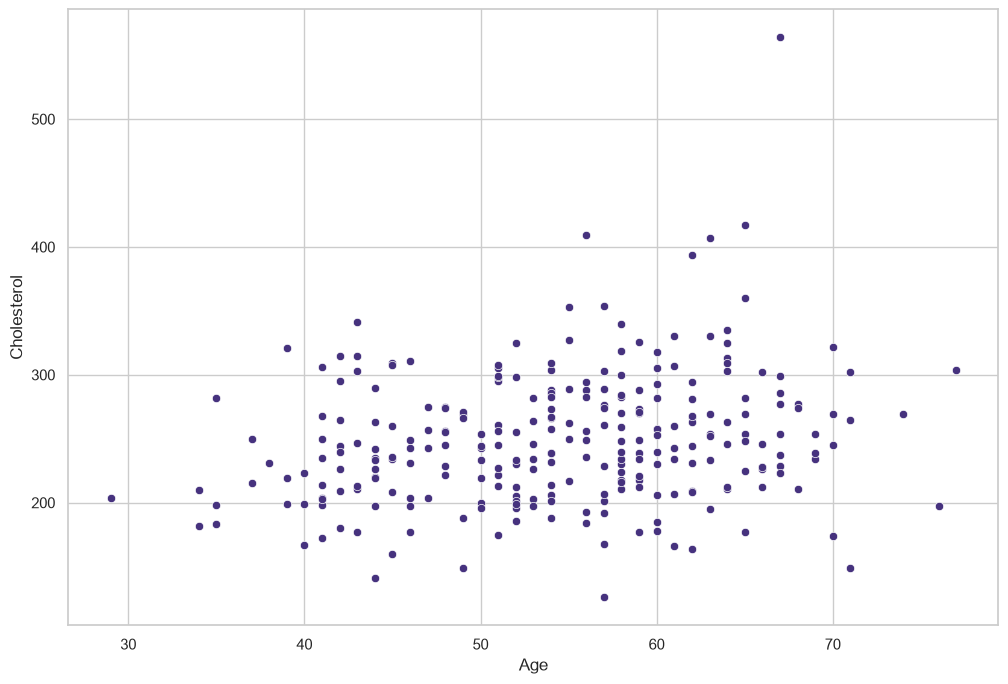

In [12]:
sns.scatterplot(x="Age",y="Cholesterol",data=df)

<Axes: xlabel='Heart Disease', ylabel='count'>

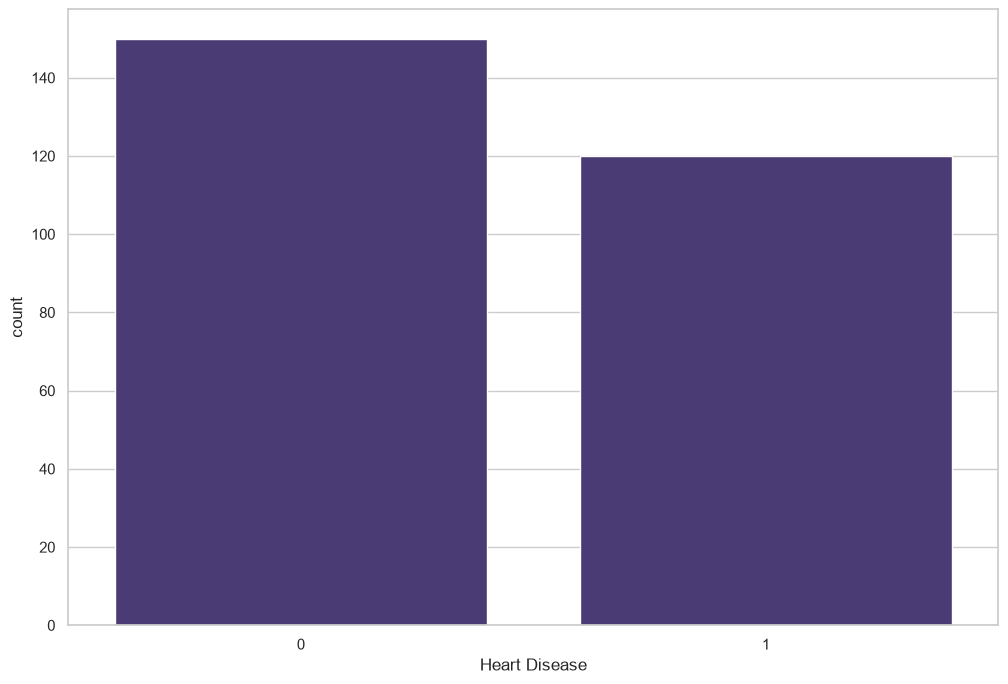

In [13]:
sns.countplot(x="Heart Disease",data=df)

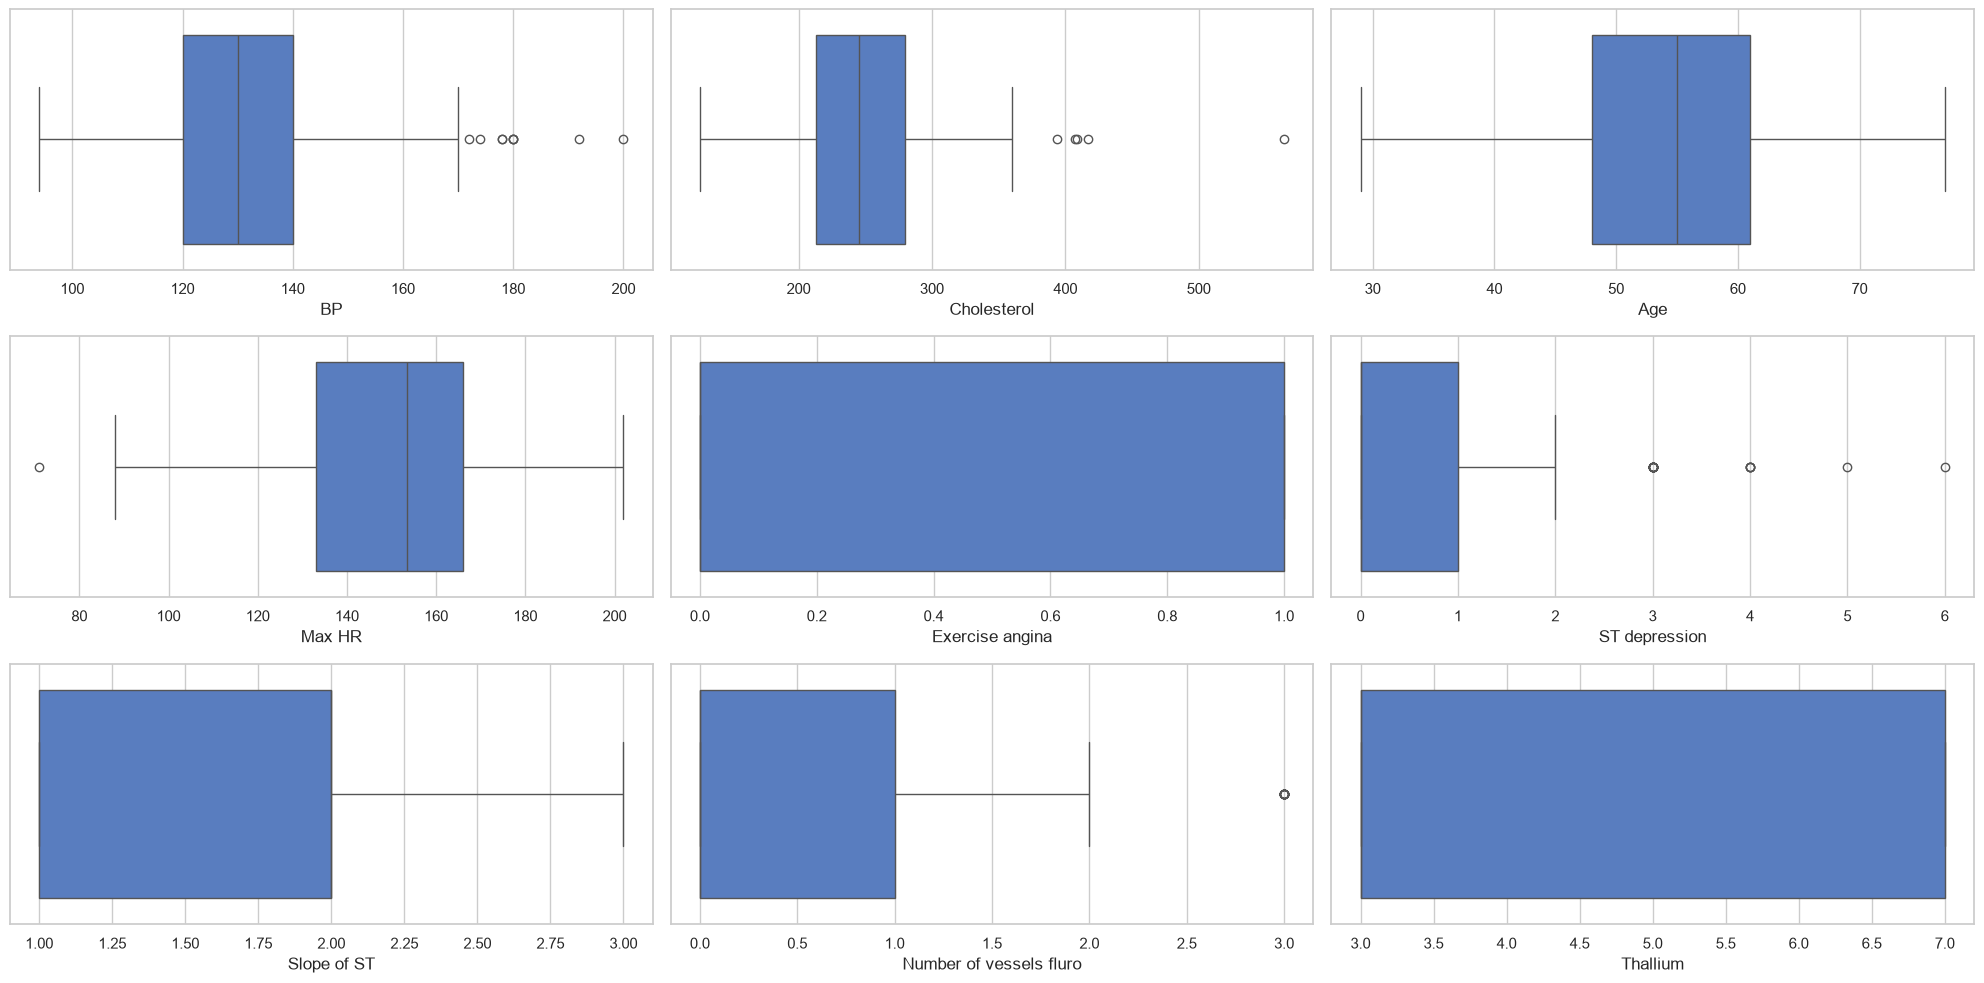

In [14]:
c = ['BP', 'Cholesterol', 'Age', 'Max HR', 'Exercise angina',
     'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

fig, ax = plt.subplots(3, 3, figsize=(20,10))
ax = ax.flatten()

for i, col in enumerate(c):
    sns.boxplot(x=df[col], ax=ax[i],palette="muted")

plt.tight_layout()
plt.show()

<Axes: xlabel='Heart Disease', ylabel='Age'>

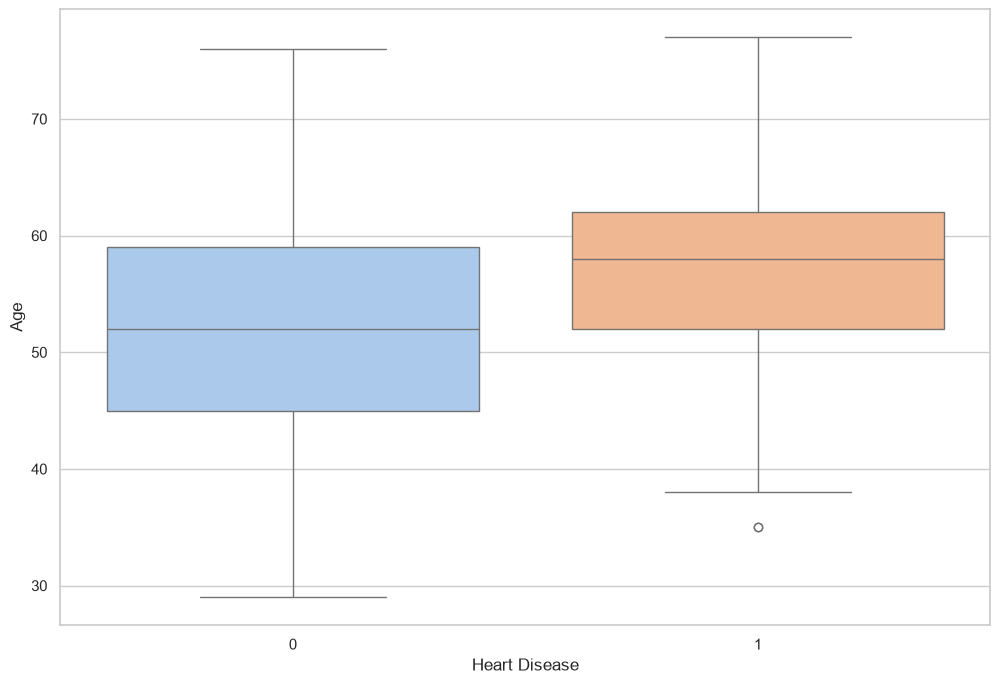

In [15]:
sns.boxplot(
    x="Heart Disease",
    y="Age",
    data=df,
    palette="pastel"
)

<Axes: xlabel='Heart Disease', ylabel='count'>

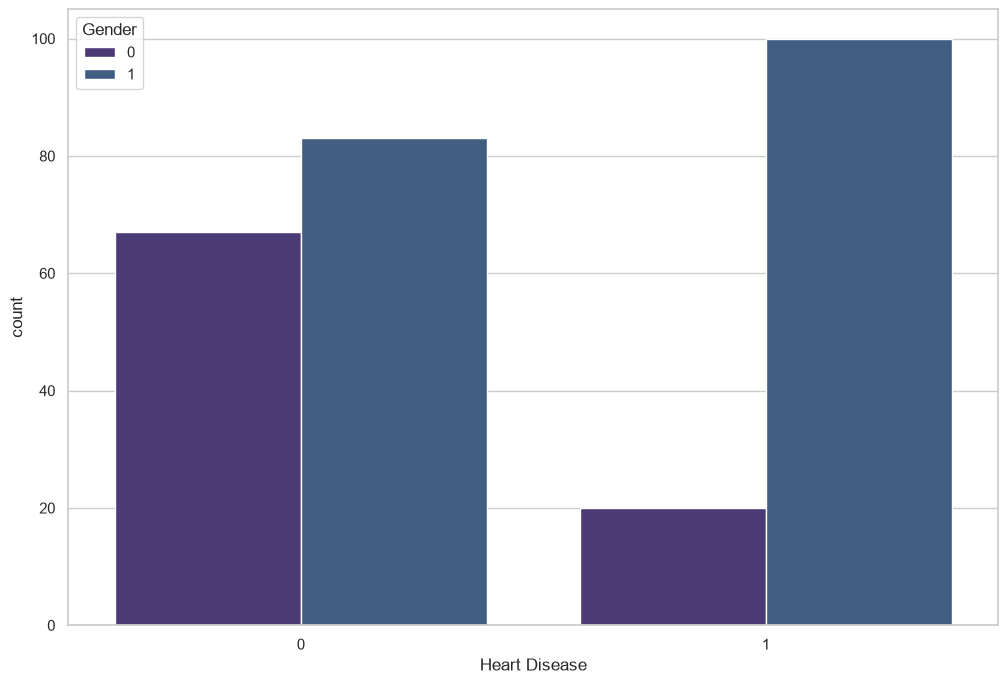

In [16]:
sns.countplot(x="Heart Disease",data=df,hue="Gender")

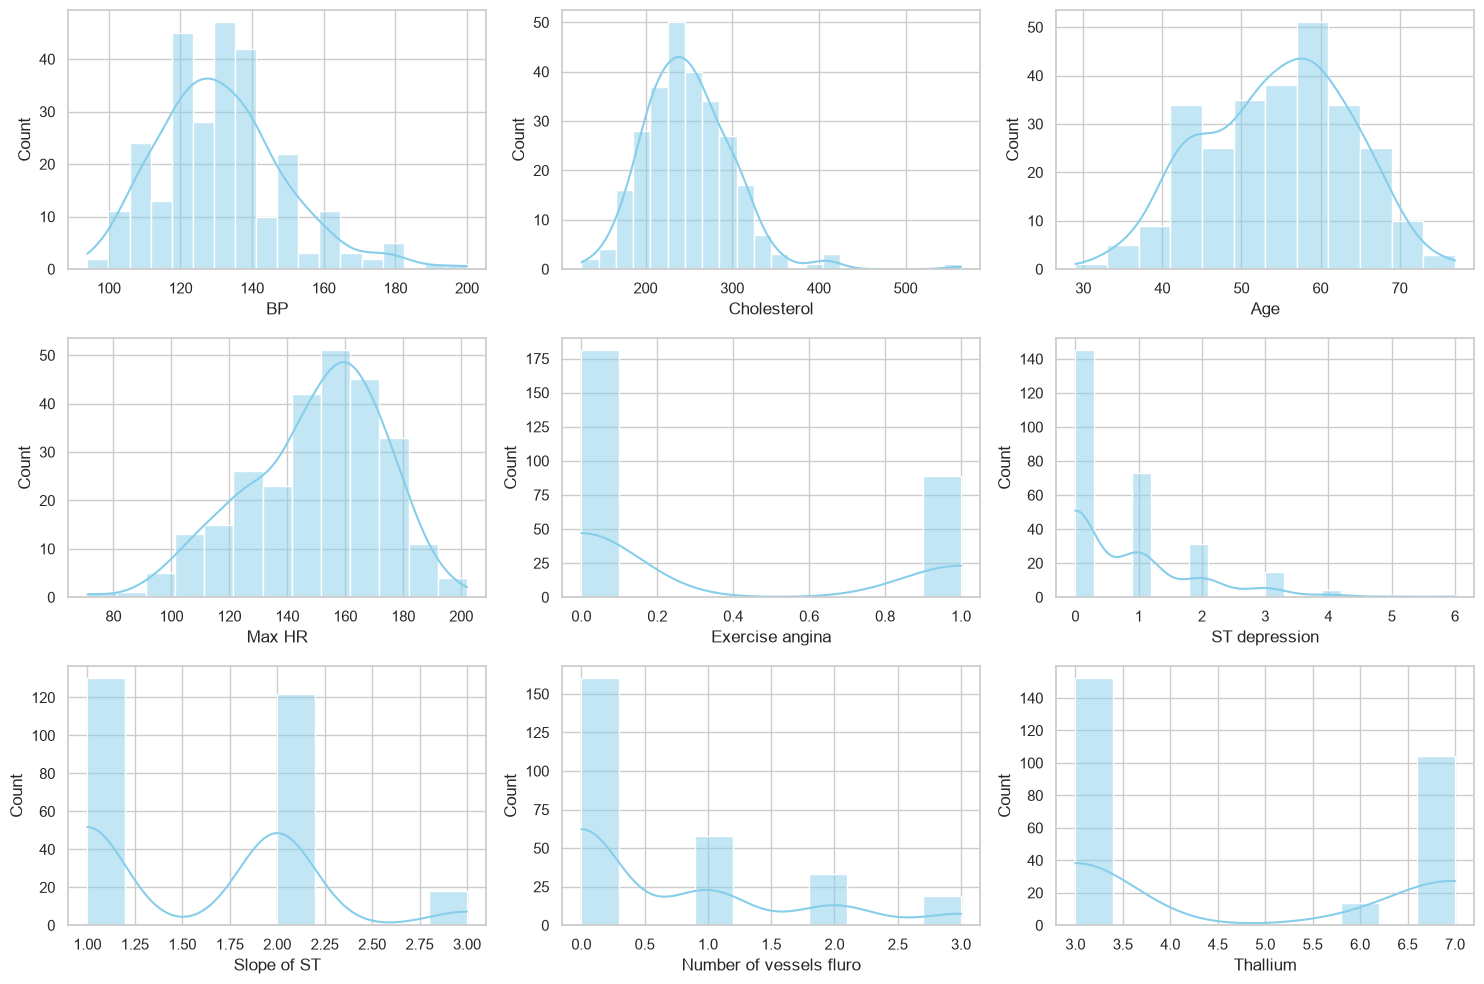

In [17]:
cl = ['BP', 'Cholesterol', 'Age', 'Max HR', 'Exercise angina',
     'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

fig,ax=plt.subplots(3,3,figsize=(15,10))
ax=ax.flatten()

for i,col in enumerate(cl):# enumerate(cl) creates a sequence of (index, value) pairs.
    sns.histplot(x=df[col],ax=ax[i],kde=True,color="skyblue")

plt.tight_layout()
plt.show()


<Axes: >

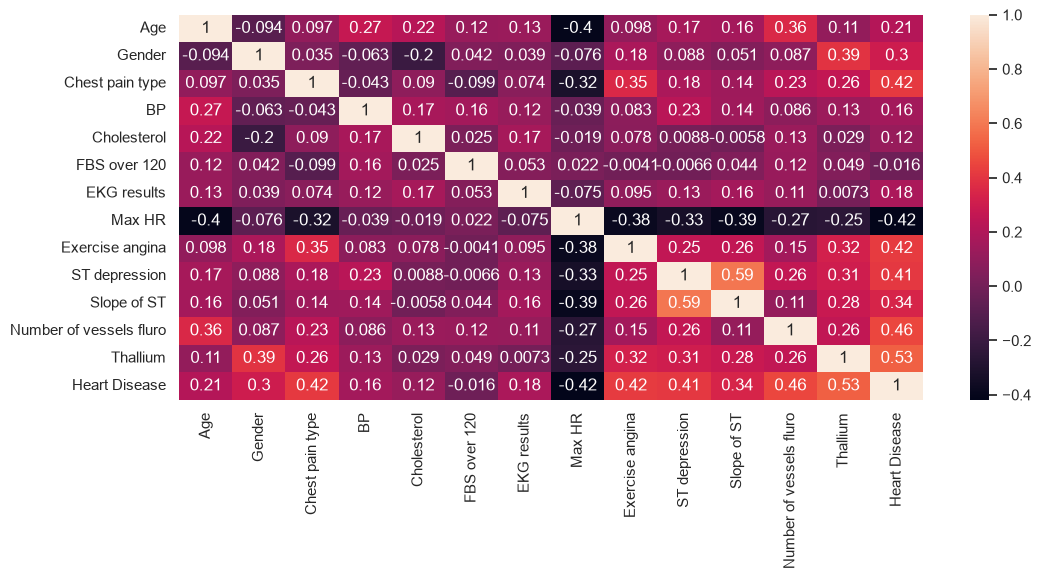

In [18]:
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [19]:


col=['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium']


# 🎯 Feature Selection

Two statistical methods are used:

- Pearson Correlation
- ANOVA F-Test

In [20]:
df_final=df[['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol','Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium','Heart Disease']].copy()
df_final=df_final.astype(int)
df_final

,Age,Gender,Chest pain type,BP,Cholesterol,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,2,3,3,1
1,67,0,3,115,564,0,1,2,0,7,0
2,57,1,2,124,261,0,0,1,0,7,1
3,64,1,4,128,263,1,0,2,1,7,0
4,74,0,2,120,269,1,0,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,0,0,1,0,7,0
266,44,1,2,120,263,0,0,1,0,7,0
267,56,0,2,140,294,0,1,2,0,3,0
268,57,1,4,140,192,0,0,2,0,6,0


In [21]:
from scipy.stats import pearsonr

selected_features=['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol','Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium']

correlations = {
    feature: pearsonr(df_final[feature], df_final['Heart Disease'])[0]
    for feature in selected_features
}# comprension dict

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)
correlation_df.sort_values(by="Pearson Correlation",ascending=False)

,Feature,Pearson Correlation
9,Thallium,0.525020
8,Number of vessels fluro,0.455336
5,Exercise angina,0.419303
2,Chest pain type,0.417436
6,ST depression,0.411289
7,Slope of ST,0.337616
1,Gender,0.297721
0,Age,0.212322
3,BP,0.155383
4,Cholesterol,0.118021


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df_final[selected_features]
y = df_final["Heart Disease"]

selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_
})

print(scores.sort_values("p_value"))

                   Feature     F_score       p_value
9                 Thallium  101.985020  1.572351e-20
8  Number of vessels fluro   70.098369  3.173059e-15
5          Exercise angina   57.169619  6.383031e-13
2          Chest pain type   56.554610  8.261539e-13
6            ST depression   54.564558  1.910645e-12
7              Slope of ST   34.477790  1.271931e-08
1                   Gender   26.065252  6.266938e-07
0                      Age   12.651991  4.434804e-04
3                       BP    6.630618  1.056095e-02
4              Cholesterol    3.785661  5.273889e-02


# ⚙️ Data Preparation

In [23]:
df_ready=df_final[['Thallium','Exercise angina','BP','Number of vessels fluro','Chest pain type','Age','ST depression','Gender','Heart Disease']].copy()

In [24]:
# Defining feature matrix X and target vector y using optimized features
# We drop 'Heart Disease' and non-essential features identified during selection
X = df_ready.drop("Heart Disease", axis=1)
y = df_ready["Heart Disease"]

print(f"Feature matrix shape: {X.shape}")
print(f"Features included: {list(X.columns)}")

Feature matrix shape: (270, 8)
Features included: ['Thallium', 'Exercise angina', 'BP', 'Number of vessels fluro', 'Chest pain type', 'Age', 'ST depression', 'Gender']


# ✂️ Train-Test Split

In [25]:
log_model=LogisticRegression(C= 1, penalty= 'l1', solver= 'liblinear')
knn_model=KNeighborsClassifier()
svc_model=SVC()
rf_model=RandomForestClassifier()
xg_model=XGBClassifier()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# 📏 Feature Scaling

In [26]:
scale=StandardScaler()

X_train = scale.fit_transform(X_train)

X_test = scale.transform(X_test) #the model learned patterns based on training dataset

log_model=log_model.fit(X_train,y_train)

log_model_pred=log_model.predict(X_test)

# 📈 Cross Validation

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = [
    log_model,
    knn_model,
    svc_model,
    rf_model,
    xg_model
]

for model in models:
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n{model.__class__.__name__}")
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())


LogisticRegression
Fold Accuracies: [0.79545455 0.81395349 0.79069767 0.90697674 0.81395349]
Mean Accuracy: 0.8242071881606765
Std Dev: 0.042451567926667176

KNeighborsClassifier
Fold Accuracies: [0.77272727 0.74418605 0.76744186 0.88372093 0.8372093 ]
Mean Accuracy: 0.8010570824524311
Std Dev: 0.05158908940633258

SVC
Fold Accuracies: [0.86363636 0.76744186 0.81395349 0.90697674 0.81395349]
Mean Accuracy: 0.8331923890063425
Std Dev: 0.0478212698686217

RandomForestClassifier
Fold Accuracies: [0.88636364 0.69767442 0.8372093  0.90697674 0.81395349]
Mean Accuracy: 0.8284355179704017
Std Dev: 0.07336152219873149

XGBClassifier
Fold Accuracies: [0.77272727 0.60465116 0.8372093  0.86046512 0.8372093 ]
Mean Accuracy: 0.7824524312896407
Std Dev: 0.09358469817170927


### 📊 Comparative Model Performance
We will now compare the cross-validation results of different classifiers to identify the most robust model.

In [28]:
results = []
for model in models:
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results.append({
        'Model': model.__class__.__name__,
        'Mean Accuracy': cv_scores.mean(),
        'Std Dev': cv_scores.std()
    })

summary_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)
display(summary_df.style.background_gradient(cmap='Greens'))

,Model,Mean Accuracy,Std Dev
2,SVC,0.833192,0.047821
3,RandomForestClassifier,0.828436,0.081731
0,LogisticRegression,0.824207,0.042452
1,KNeighborsClassifier,0.801057,0.051589
4,XGBClassifier,0.782452,0.093585


In [29]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

models = [
    log_model,
    knn_model,
    svc_model,
    rf_model,
    xg_model
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


for model in models:

    y_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )

    print("\n========================")
    print(model.__class__.__name__)
    print("========================")

    print(classification_report(y_train, y_pred))
    print(accuracy_score(y_train,y_pred))
y_pred.shape


LogisticRegression
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       117
           1       0.81      0.80      0.81        99

    accuracy                           0.82       216
   macro avg       0.82      0.82      0.82       216
weighted avg       0.82      0.82      0.82       216

0.8240740740740741

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       117
           1       0.80      0.76      0.78        99

    accuracy                           0.80       216
   macro avg       0.80      0.80      0.80       216
weighted avg       0.80      0.80      0.80       216

0.8009259259259259

SVC
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       117
           1       0.82      0.81      0.82        99

    accuracy                           0.83       216
   macro avg       0.83      0.83      0.83

(216,)

# 🤖 Model Training


In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for LogisticRegression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' works with both l1 and l2 penalties
}

# Create a GridSearchCV object
grid_search_log_model = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=cv, # Using the same cross-validation strategy as before
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit the GridSearchCV to the training data
grid_search_log_model.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search_log_model.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_log_model.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy for Logistic Regression: 0.8242071881606765


In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate the best model on the test set
best_log_model = grid_search_log_model.best_estimator_
best_log_model_pred = best_log_model.predict(X_test)

print("\nClassification Report for Best Logistic Regression Model on Test Set:")
print(classification_report(y_test, best_log_model_pred))
print("\nConfusion Matrix for Best Logistic Regression Model on Test Set:")
print(confusion_matrix(y_test, best_log_model_pred))
print("\nAccuracy Score for Best Logistic Regression Model on Test Set:", accuracy_score(y_test, best_log_model_pred))


Classification Report for Best Logistic Regression Model on Test Set:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        33
           1       0.88      0.71      0.79        21

    accuracy                           0.85        54
   macro avg       0.86      0.83      0.84        54
weighted avg       0.86      0.85      0.85        54


Confusion Matrix for Best Logistic Regression Model on Test Set:
[[31  2]
 [ 6 15]]

Accuracy Score for Best Logistic Regression Model on Test Set: 0.8518518518518519


### 📈 Model Interpretability & Visualization
Understanding why a model makes a decision is just as important as its accuracy. Below, we visualize the model's errors and the features it prioritized.

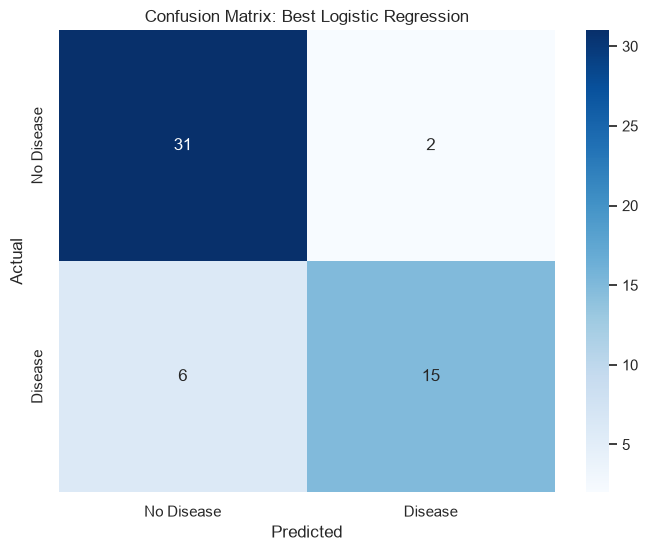

In [32]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_log_model_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Best Logistic Regression')
plt.show()

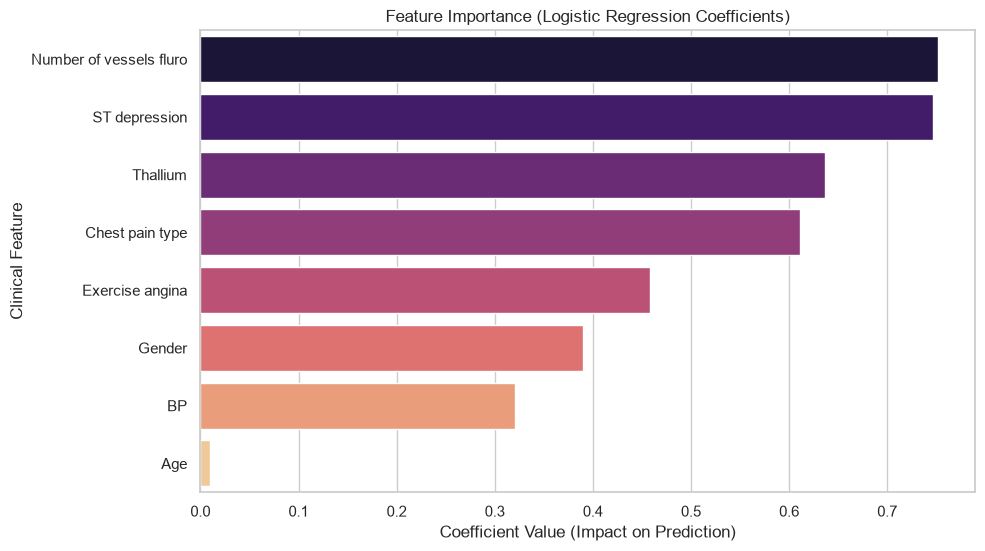

In [34]:
# Extracting Coefficients for Feature Importance
model_features=['Thallium','Exercise angina','BP','Number of vessels fluro','Chest pain type','Age','ST depression','Gender']
feature_importance = pd.DataFrame({
    'Feature': model_features,
    'Importance': best_log_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Prediction)')
plt.ylabel('Clinical Feature')
plt.show()

# 🔥 Predictions

In [ ]:


# The scaler was fitted on the training set which only contained specific columns
# Let's identify the features used in the final model based on the 'X' dataframe from cell 05be0770
model_features = X.columns.tolist()

# Create a 'healthy' person profile matching the features in 'X'
# Features: ['Thallium', 'Exercise angina', 'BP', 'Number of vessels fluro', 'Chest pain type', 'Age', 'ST depression', 'Gender']
healthy_person = [
    3,    # Thallium (normal)
    0,    # Exercise angina (no)
    120,  # BP
    0,    # Number of vessels fluro
    1,    # Chest pain type
    40,   # Age
    0,    # ST depression
    0     # Gender (female)
]

# Create an 'unhealthy' person profile
unhealthy_person = [
    7,    # Thallium (defect)
    1,    # Exercise angina (yes)
    160,  # BP
    3,    # Number of vessels fluro
    4,    # Chest pain type
    65,   # Age
    2,    # ST depression
    1     # Gender (male)
]

# Create DataFrame
sample_data = pd.DataFrame([healthy_person, unhealthy_person], columns=model_features)

# Scale the sample data using the scaler fitted in cell 5c4e699c
sample_data_scaled = scale.transform(sample_data)

# Predict
predictions = best_log_model.predict(sample_data_scaled)

# Map predictions
prediction_map = {0: 'Absence', 1: 'Presence'}

print(f"Prediction for Healthy Person: {prediction_map[predictions[0]]} of Heart Disease")
print(f"Prediction for Unhealthy Person: {prediction_map[predictions[1]]} of Heart Disease")

Prediction for Healthy Person: Absence of Heart Disease
Prediction for Unhealthy Person: Presence of Heart Disease


## 🏁 Model Selection Summary & Final Verdict

After a systematic evaluation of multiple machine learning algorithms, here is a summary of our findings:

### 1. Model Comparison
We compared five different classifiers using 5-fold Stratified Cross-Validation. The results showed:
- **SVC (Support Vector Classifier)** and **Logistic Regression** were the top performers, both achieving mean cross-validation accuracies above 82%.
- **Random Forest** and **XGBoost** showed slightly lower performance, likely due to the small size of the dataset (270 samples), where simpler linear models often generalize better.

### 2. Final Model Choice: Logistic Regression
We selected **Logistic Regression** for the final deployment because:
- **Interpretability:** It provides clear coefficients that align with clinical understanding of heart disease risk factors.
- **Performance:** After hyperparameter tuning (`C=1`, `penalty='l1'`), it achieved an **Accuracy of 85.2%** on the unseen test set.
- **Reliability:** The confusion matrix shows a high recall for the 'Absence' class and strong precision, minimizing false alarms in a clinical screening context.

### 3. Feature Importance
Statistical analysis (Pearson Correlation & F-scores) confirmed that **Thallium Stress Test results**, **Number of Major Vessels**, and **Exercise Induced Angina** are the most significant predictors of heart disease in this patient cohort.